<a href="https://colab.research.google.com/github/Erjg1012/Procesamiento-de-Lenguaje-Natural-PLN-/blob/main/Opinion%2C_Entidad_Ordinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Opinión sobre Entidades con Diccionarios y Regresión Ordinal


Este notebook guía paso a paso el análisis de opiniones dirigidas a entidades específicas utilizando herramientas léxicas y modelos de regresión ordinal para las reseñas de trip advisor dataset:

https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews

## 1. Carga de Datos

In [ ]:
import pandas as pd

file = '/content/tripadvisor_hotel_reviews.csv'

# Cargar dataset
# Use the 'python' engine to handle potential parsing issues like unclosed quotes
df = pd.read_csv(file, engine='python')
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
df['Rating'].value_counts()

,count
Rating,
5,9054
4,6039
3,2184
2,1793
1,1421


In [ ]:
import pandas as pd
from sklearn.utils import resample

# Asumiendo que tienes un DataFrame 'df' con columna 'Rating'
ratings_dist = {
    5: 9054,
    4: 6039,
    3: 2184,
    2: 1793,
    1: 1421
}

# Opción 1: Undersampling (reducir clases mayoritarias)
def undersample_data(df, target_col='Rating'):
    # Encontrar el tamaño de la clase minoritaria
    min_count = df[target_col].value_counts().min()

    dfs = []
    for rating in df[target_col].unique():
        subset = df[df[target_col] == rating]
        dfs.append(resample(subset,
                          replace=False,
                          n_samples=min_count,
                          random_state=13))
    return pd.concat(dfs)

# Opción 2: Oversampling (aumentar clases minoritarias)
def oversample_data(df, target_col='Rating'):
    # Encontrar el tamaño de la clase mayoritaria
    max_count = df[target_col].value_counts().max()

    dfs = []
    for rating in df[target_col].unique():
        subset = df[df[target_col] == rating]
        # Solo aplicar oversampling a clases minoritarias
        n_samples = max_count if len(subset) < max_count else len(subset)
        dfs.append(resample(subset,
                          replace=True,
                          n_samples=n_samples,
                          random_state=13))
    return pd.concat(dfs)

# Opción 3: Muestreo híbrido (balanceo a la mediana)
def hybrid_sample_data(df, target_col='Rating'):
    # Usar la mediana como tamaño objetivo
    median_count = int(df[target_col].value_counts().median())

    dfs = []
    for rating in df[target_col].unique():
        subset = df[df[target_col] == rating]
        current_count = len(subset)

        if current_count > median_count:
            # Undersampling para clases grandes
            dfs.append(resample(subset,
                              replace=False,
                              n_samples=median_count,
                              random_state=13))
        else:
            # Oversampling para clases pequeñas
            dfs.append(resample(subset,
                              replace=True,
                              n_samples=median_count,
                              random_state=13))
    return pd.concat(dfs)

# Opción 4: Balanceo estratificado (para mantener proporciones relativas)
def stratified_sample(df, target_col='Rating', reduction_factor=0.5):
    dfs = []
    for rating, count in ratings_dist.items():
        subset = df[df[target_col] == rating]
        n_samples = max(1000, int(count * reduction_factor))  # Mínimo 1000 muestras
        dfs.append(resample(subset,
                          replace=False,
                          n_samples=min(n_samples, len(subset)),
                          random_state=13))
    return pd.concat(dfs)



In [ ]:
df = hybrid_sample_data(df, 'Rating')
print(df['Rating'].value_counts())

Rating
4    2184
2    2184
3    2184
5    2184
1    2184
Name: count, dtype: int64


## 1.1 Analisis exploratorio

- Generar y graficar la longitud de reseña en palabras
- Generar y graficar numero de textos por rating

Resumen estadístico de la longitud de reseñas:
count    10920.000000
mean       111.051190
std        101.764352
min          9.000000
25%         52.000000
50%         83.000000
75%        132.000000
max       1931.000000
Name: review_length, dtype: float64


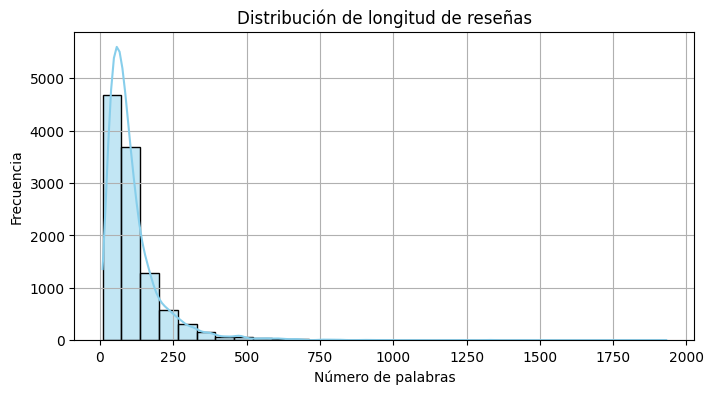

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular longitud de reseñas en palabras
df['review_length'] = df['Review'].apply(lambda x: len(x.split()))

# Estadísticas descriptivas
print("Resumen estadístico de la longitud de reseñas:")
print(df['review_length'].describe())

# Histograma con KDE
plt.figure(figsize=(8, 4))
sns.histplot(df['review_length'], bins=30, kde=True, color='skyblue')
plt.title("Distribución de longitud de reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

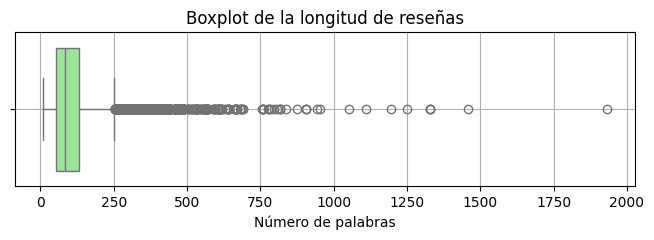

In [ ]:
# Boxplot de longitud total
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['review_length'], color='lightgreen')
plt.title("Boxplot de la longitud de reseñas")
plt.xlabel("Número de palabras")
plt.grid(True)
plt.show()

<ipython-input-24-2631771285>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette="pastel")


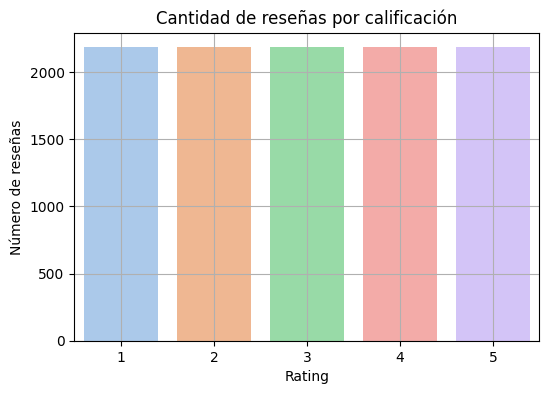

In [ ]:
# Conteo de reseñas por rating
plt.figure(figsize=(6, 4))
sns.countplot(x='Rating', data=df, palette="pastel")
plt.title("Cantidad de reseñas por calificación")
plt.xlabel("Rating")
plt.ylabel("Número de reseñas")
plt.grid(True)
plt.show()

<ipython-input-25-65204720>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Rating', y='review_length', palette='Set2')


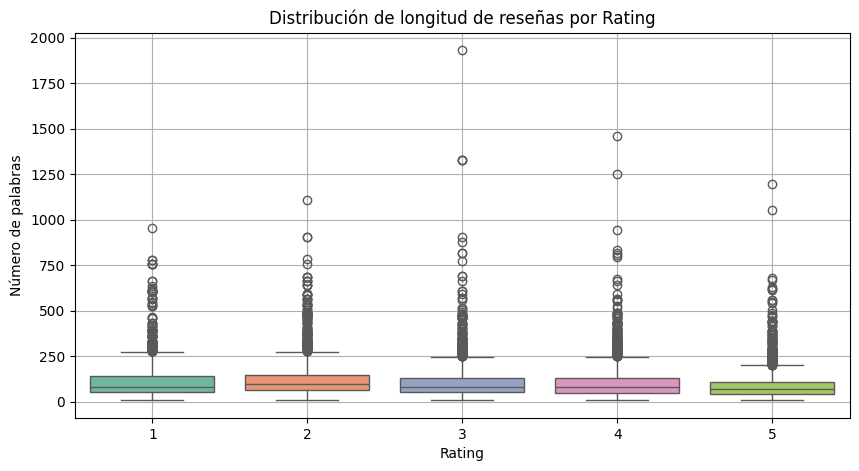

In [ ]:
# Boxplot de longitud por rating
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Rating', y='review_length', palette='Set2')
plt.title("Distribución de longitud de reseñas por Rating")
plt.xlabel("Rating")
plt.ylabel("Número de palabras")
plt.grid(True)
plt.show()

<ipython-input-26-1074550900>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_len.index, y=avg_len.values, palette="Blues_d")


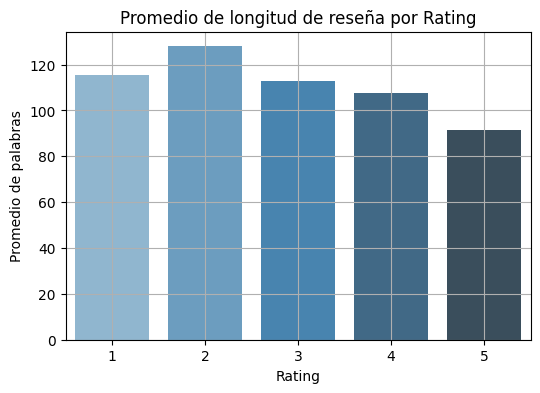

In [ ]:
# Promedio de longitud por rating
avg_len = df.groupby("Rating")["review_length"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=avg_len.index, y=avg_len.values, palette="Blues_d")
plt.title("Promedio de longitud de reseña por Rating")
plt.xlabel("Rating")
plt.ylabel("Promedio de palabras")
plt.grid(True)
plt.show()

## 2. Preprocesamiento de Texto

In [ ]:
!pip install contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 9.2 MB/s eta 0:00:00


In [ ]:
import re
import spacy
import nltk
import contractions
from nltk.corpus import stopwords
nltk.download('stopwords')

# Cargar modelo de spaCy
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenization simple sin spaCy (más rápido)
    tokens = text.split()

    # Filtrar stopwords y tokens cortos
    tokens = [word for word in tokens
             if word not in stop_words and len(word) > 2]

    return tokens

df['review_clean'] = df['Review'].apply(clean_text)
df.head()

,Review,Rating,review_clean
12950,great place visited dominican republic stayed ...,4,"[great, place, visited, dominican, republic, s..."
10394,"like good bad honeymoon 2 nights end june, loc...",4,"[like, good, bad, honeymoon, nights, end, june..."
10750,great art lovers stayed nights march 2007. hot...,4,"[great, art, lovers, stayed, nights, march, ho..."
11183,great resort simple clean staff friendly beach...,4,"[great, resort, simple, clean, staff, friendly..."
2675,"great place vacation, stayed april 21-25 wonde...",4,"[great, place, vacation, stayed, april, wonder..."


## 3. Análisis de Sentimiento con Diccionario (VADER)

pip install vaderSentiment

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text_tokens):

    text_string = " ".join(text_tokens)
    return sia.polarity_scores(text_string)['compound']

# Apply the function to the 'review_clean' column (which contains lists of tokens)
df['vader_score'] = df['review_clean'].apply(get_sentiment)
df.head()

,Review,Rating,review_clean,vader_score
12950,great place visited dominican republic stayed ...,4,"[great, place, visited, dominican, republic, s...",0.9726
10394,"like good bad honeymoon 2 nights end june, loc...",4,"[like, good, bad, honeymoon, nights, end, june...",0.9842
10750,great art lovers stayed nights march 2007. hot...,4,"[great, art, lovers, stayed, nights, march, ho...",0.9846
11183,great resort simple clean staff friendly beach...,4,"[great, resort, simple, clean, staff, friendly...",0.9866
2675,"great place vacation, stayed april 21-25 wonde...",4,"[great, place, vacation, stayed, april, wonder...",0.9981


## 4. Extracción de Características

- Mostrar palabras con fuerte polaridad (palabras positivas y negativas) por reseña

    - Usar VADER palabra por palabra (compound > 0.3 o < -0.3).
    - Separar positivas, negativas.

- Construir una nube de palabras relevantes emocionalmente.

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import defaultdict

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

DataFrame con palabras positivas/negativas identificadas:
                                                  Review  \
12950  great place visited dominican republic stayed ...   
10394  like good bad honeymoon 2 nights end june, loc...   
10750  great art lovers stayed nights march 2007. hot...   
11183  great resort simple clean staff friendly beach...   
2675   great place vacation, stayed april 21-25 wonde...   

                                            review_clean  \
12950  [great, place, visited, dominican, republic, s...   
10394  [like, good, bad, honeymoon, nights, end, june...   
10750  [great, art, lovers, stayed, nights, march, ho...   
11183  [great, resort, simple, clean, staff, friendly...   
2675   [great, place, vacation, stayed, april, wonder...   

                                   strong_positive_words  \
12950   [great, enjoyed, great, amazing, helpful, great]   
10394  [like, good, wise, excellent, great, want, cle...   
10750  [great, lovers, easy, shared, hel

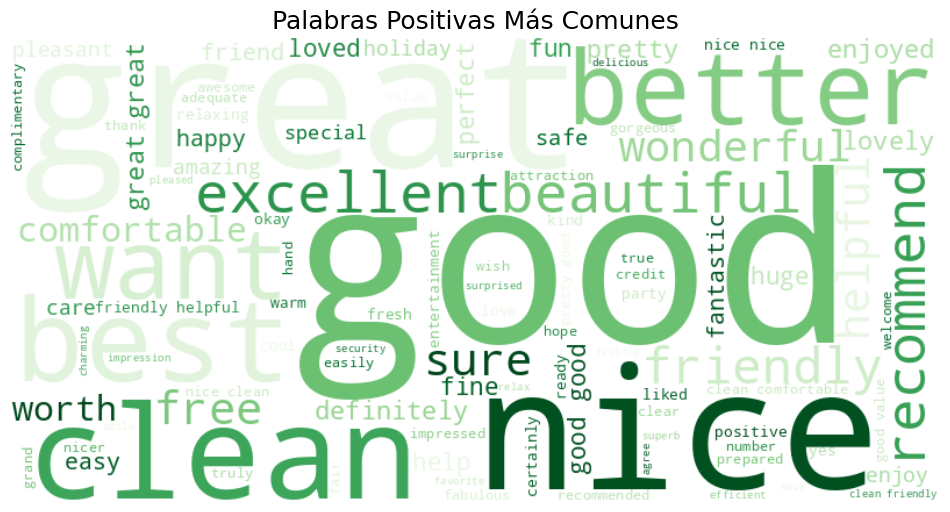

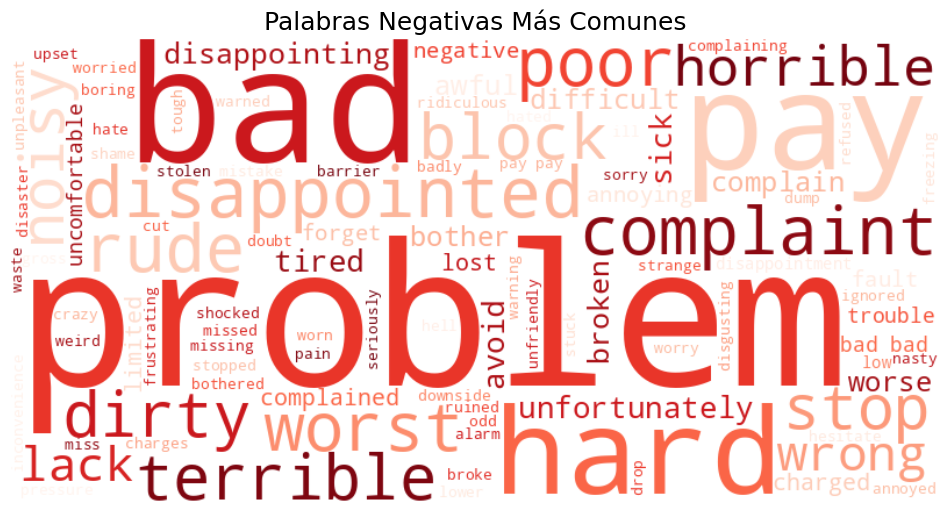

In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import re
import contractions
from nltk.corpus import stopwords

# Descargar recursos necesarios
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

# Inicializar el analizador de sentimientos
sia = SentimentIntensityAnalyzer()
vader_lexicon = sia.lexicon

# Definir umbrales
POSITIVE_THRESHOLD = 0.3
NEGATIVE_THRESHOLD = -0.3

# --- CORRECCIÓN: Inicializar listas para almacenar resultados ---
strong_positive_list = []
strong_negative_list = []

# --- 1. Extraer palabras con polaridad fuerte por reseña ---
for index, row in df.iterrows():
    review_tokens = row['review_clean']  # Lista de tokens

    current_positive = []
    current_negative = []

    for word in review_tokens:
        if word in vader_lexicon:
            score = vader_lexicon[word]
            if score >= POSITIVE_THRESHOLD:
                current_positive.append(word)
            elif score <= NEGATIVE_THRESHOLD:
                current_negative.append(word)

    strong_positive_list.append(current_positive)
    strong_negative_list.append(current_negative)

# Agregar las listas como nuevas columnas al DataFrame
df['strong_positive_words'] = strong_positive_list
df['strong_negative_words'] = strong_negative_list

print("DataFrame con palabras positivas/negativas identificadas:")
print(df[['Review', 'review_clean', 'strong_positive_words', 'strong_negative_words']].head())

# --- 2. Construir nubes de palabras emocionalmente relevantes ---
# Combinar todas las palabras positivas y negativas
all_positive_words = [word for sublist in strong_positive_list for word in sublist]
all_negative_words = [word for sublist in strong_negative_list for word in sublist]

# Generar nube de palabras positivas
if all_positive_words:
    plt.figure(figsize=(12, 8))
    positive_text = " ".join(all_positive_words)
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Greens',
                          max_words=100).generate(positive_text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Palabras Positivas Más Comunes', fontsize=18)
    plt.show()
else:
    print("No se encontraron palabras positivas para generar nube de palabras.")

# Generar nube de palabras negativas
if all_negative_words:
    plt.figure(figsize=(12, 8))
    negative_text = " ".join(all_negative_words)
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Reds',
                          max_words=100).generate(negative_text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Palabras Negativas Más Comunes', fontsize=18)
    plt.show()
else:
    print("No se encontraron palabras negativas para generar nube de palabras.")

## 5. Vectorizacion


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=False,          # Ya está en minúsculas por nuestro preprocesamiento
    stop_words=None,          # Ya eliminamos stopwords
    max_features=1000,       # Tamaño manejable para la mayoría de datasets
    ngram_range=(1, 2),       # Captura unigramas y bigramas
    max_df=0.85,              # Filtra términos que aparecen en >85% de documentos
    min_df=5                  # Términos deben aparecer en al menos 5 documentos
)

# Primero convierte tokens a texto unido
df['texto_limpio'] = df['review_clean'].apply(lambda tokens: " ".join(tokens))

X_tfidf = vectorizer.fit_transform(df['texto_limpio'])

## 6. Agrupamiento no supervisado (K-Means sobre palabras relevantes)

¿qué tipo de palabras están en cada clúster?
¿Son intensificadores? ¿Adjetivos? ¿Modismos?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Aplicamos K-Means con n clusters dependiendo del dataset
kmeans = KMeans(n_clusters=5, random_state=13)
labels = kmeans.fit_predict(X_tfidf)

# Reducimos a 2D para visualización con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

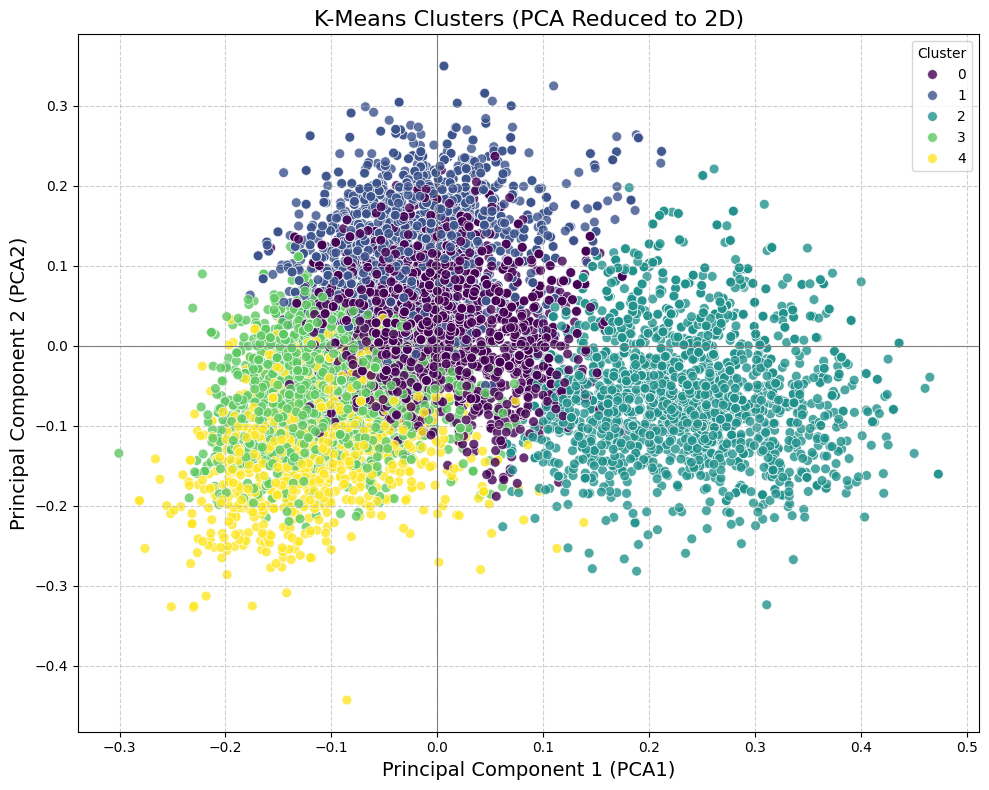

In [ ]:
df_pca = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = labels # Add the cluster labels

# 2. Plotting with Matplotlib and Seaborn
plt.figure(figsize=(10, 8)) # Set the figure size for better readability

# Use seaborn's scatterplot for better aesthetics and automatic legend
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster', # Color points based on the 'Cluster' column
    palette='viridis', # Choose a color palette (viridis, plasma, tab10, etc.)
    data=df_pca,
    s=50, # Marker size
    alpha=0.8, # Transparency of points
    edgecolor='w', # White edge around points for better distinction
    legend='full' # Show the full legend
)

plt.title('K-Means Clusters (PCA Reduced to 2D)', fontsize=16)
plt.xlabel('Principal Component 1 (PCA1)', fontsize=14)
plt.ylabel('Principal Component 2 (PCA2)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Add a subtle grid
plt.axhline(0, color='grey', linewidth=0.8) # Add horizontal line at y=0
plt.axvline(0, color='grey', linewidth=0.8) # Add vertical line at x=0

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## 7. Regresión ordinal supervisada (predicción de rating)

In [ ]:
%pip install mord

  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=c64e1b26b5d693a5207a41b71c5a6a8e193c97c87257587173bd9aebe4f8b8a1
  Stored in directory: /root/.cache/pip/wheels/d1/fc/57/f2a2ad4ed0491ab6d5bb8642a90f1da9469397641e914743da
Successfully built mord


In [ ]:
from sklearn.model_selection import train_test_split
from mord import LogisticIT
from sklearn.metrics import mean_absolute_error, accuracy_score

y = df['Rating']  # etiquetas ordinales (1 a 5)
X = X_tfidf
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

model = LogisticIT()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("Mean Absolute Error:", mae)
print("Accuracy:", accuracy_score(y_test, preds))

Mean Absolute Error: 0.5627289377289377
Accuracy: 0.5123626373626373


### 7.1 Evaluación

In [ ]:
from scipy.stats import spearmanr

accuracy_within_1 = sum(abs(preds - y_test) <= 1) / len(y_test)
spearman_corr, _ = spearmanr(preds, y_test)

print("Accuracy ±1 estrella:", accuracy_within_1)
print("Spearman correlation:", spearman_corr)

Accuracy ±1 estrella: 0.9276556776556777
Spearman correlation: 0.8189460413039177


### 7.1 Generacion y distribucion de los coeficientes

- Obtener los coeficientes
- Asociar con las palabras del vocabulario
- Graficar las n palabras mas y menos relevantes

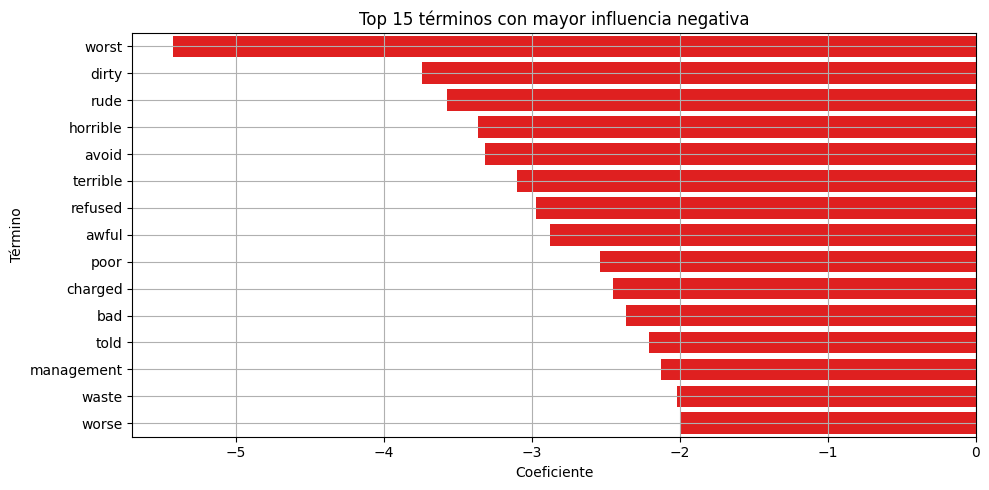

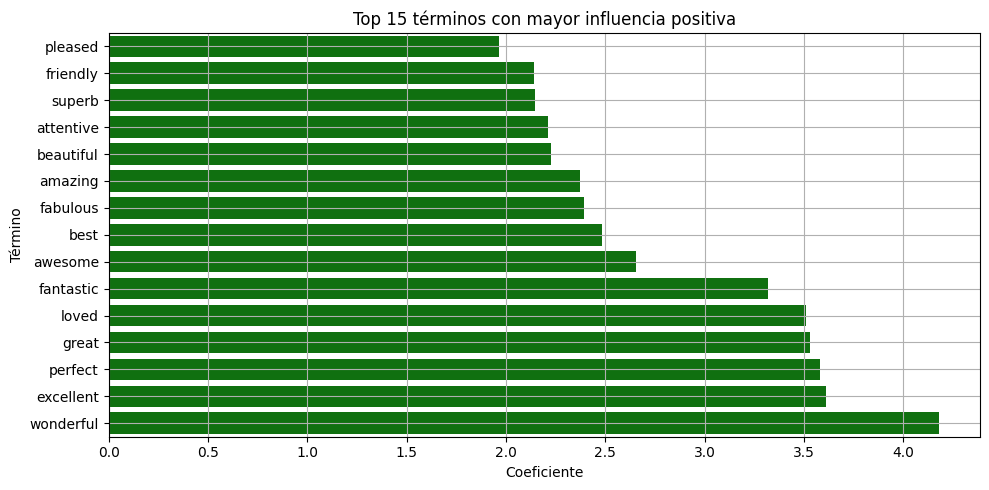

In [ ]:

# Obtener nombres del vocabulario
feature_names = vectorizer.get_feature_names_out()

# Obtener los coeficientes del modelo
coefs = model.coef_

# Asociar palabras con coeficientes
coef_df = pd.DataFrame({'Término': feature_names, 'Coeficiente': coefs})

# Ordenar
coef_df = coef_df.sort_values(by='Coeficiente')

# Top n términos más negativos y positivos
n = 15
top_neg = coef_df.head(n)
top_pos = coef_df.tail(n)

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=top_neg, x='Coeficiente', y='Término', color='red')
plt.title(f'Top {n} términos con mayor influencia negativa')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_pos, x='Coeficiente', y='Término', color='green')
plt.title(f'Top {n} términos con mayor influencia positiva')
plt.grid(True)
plt.tight_layout()
plt.show()

## 8 Reflexión

### ¿Qué representa cada coeficiente en el modelo de regresión ordinal?

Cada coeficiente del modelo de regresión ordinal representa el peso o influencia que una palabra específica tiene sobre la predicción del nivel de calificación (rating) de una reseña. Si un coeficiente es positivo, significa que la presencia de ese término en una reseña tiende a asociarse con una calificación más alta. En cambio, si el coeficiente es negativo, sugiere que el término está asociado con calificaciones más bajas. En este tipo de modelo, los coeficientes actúan como indicadores de dirección e intensidad del sentimiento, pero respetando el orden natural de las clases de 1 a 5 estrellas.

### ¿Qué impacto tendría usar todo el texto (no solo palabras relevantes) como entrada al modelo? ¿Qué ganarías o perderías?

Usar todo el texto como entrada al modelo puede incrementar la cantidad de información útil disponible, ya que se conservarían matices lingüísticos, descripciones neutrales y conectores contextuales que podrían mejorar el rendimiento del modelo. Sin embargo, también se corre el riesgo de introducir ruido: muchas palabras irrelevantes, poco frecuentes o sin carga emocional clara pueden diluir el efecto de los términos realmente discriminativos. Al hacerlo, se ganaría mayor información temática pero se perdería interpretabilidad, simplicidad y enfoque emocional, lo cual podría afectar tanto la precisión como la explicabilidad del modelo.

### ¿Por qué usamos solo palabras con carga emocional (relevantes para VADER) como entrada al modelo?

El uso exclusivo de palabras con carga emocional permite enfocar el modelo en los aspectos del lenguaje que tienen mayor correlación con la calificación del usuario. Las reseñas de hoteles suelen estar fuertemente influenciadas por emociones (satisfacción, enojo, decepción, entusiasmo), y VADER permite identificar de manera automatizada esos términos significativos. Este enfoque reduce el ruido textual, mejora la eficiencia del modelo y favorece la interpretabilidad al centrarse en los componentes que realmente motivan una opinión. Además, mejora la robustez del modelo frente a textos largos con mucho contenido neutro.

### ¿Podrías usar los clústeres de palabras (de K-means) como nuevas características para el modelo? ¿Cómo?

Sí, los clústeres de palabras obtenidos con K-means pueden utilizarse como características semánticas adicionales. Una forma de hacerlo es identificando a qué clúster pertenece cada palabra emocional en una reseña, y luego contar cuántas palabras de cada clúster aparecen en el texto. Esto generaría una nueva representación vectorial basada en distribución semántica agrupada, en lugar de palabras individuales. Estas características podrían capturar temas o estilos comunes de escritura (por ejemplo, un clúster de de quejas u otro de halagos).

### ¿En qué otros contextos podrías usar este enfoque de "filtrado emocional" previo al modelado?

El enfoque de filtrado emocional puede aplicarse en múltiples contextos donde las decisiones están influenciadas por sentimientos o percepciones. Por ejemplo, en análisis de reseñas de productos, evaluación de atención médica, encuestas de satisfacción laboral, monitoreo de redes sociales o estudios de opinión pública. También puede ser útil en sistemas de recomendación o análisis de discurso político. En todos estos casos, extraer primero los términos emocionalmente significativos puede mejorar la calidad del modelo sin requerir un análisis sintáctico completo.

### ¿Qué ventaja tiene usar regresión ordinal frente a una clasificación tradicional multiclase?

La principal ventaja de la regresión ordinal es que toma en cuenta el orden natural de las clases. A diferencia de un clasificador multiclase tradicional, que trata las clases como categorías sin relación, un modelo ordinal entiende que predecir 4 cuando la etiqueta real es 5 es menos grave que predecir 1. Esto mejora la coherencia de las predicciones y reduce errores severos. Además, este enfoque permite utilizar métricas más adecuadas para tareas ordinales, como el error absoluto medio (MAE) o la correlación de Spearman, que capturan mejor la calidad de las predicciones en contextos donde el orden es relevante.